## 네이버 검색 API 활용


### 개요

네이버 데이터랩에서 제공하는 검색어 트렌드 API를 활용하여 특정 키워드의 검색량 추이를 분석하는 과제입니다. 시간에 따른 검색어 관심도 변화를 확인하고 데이터를 수집하여 저장합니다. 아래의 사이트에서 검색어 트렌드를 입력해서 결과를 확인할 수 있습니다.

### 준비사항

1. 네이버 개발자 센터([https://developers.naver.com](https://developers.naver.com/)) 회원가입 및 로그인
2. 애플리케이션 등록 (데이터랩(검색어 트렌드) API 사용 신청)
3. 클라이언트 ID와 시크릿 발급
4. Python 설치 및 requests 라이브러리 설치
5. VSCode 주피터 환경 설치

### 과제 요구사항

1. 네이버 데이터랩 검색어 트렌드 API활용 방법에 대해 숙지하세요.
    - https://developers.naver.com/docs/serviceapi/datalab/search/search.md#%ED%86%B5%ED%95%A9-%EA%B2%80%EC%83%89%EC%96%B4-%ED%8A%B8%EB%A0%8C%EB%93%9C
    - 주의 사항 : 보통 `get()` 함수로 호출 데이터를 가져왔으나 여기에서는 `post()` 함수로 데이터를 가져와야합니다. (API 활용 가이드 내용 및 예시 코드 확인)
2. 네이버 데이터랩 검색어 트렌드 API를 활용하여 다음 작업을 수행하세요:
    - 최소 3개 이상의 키워드에 대한 검색 트렌드 데이터 수집
    - 최근 1년간의 주간 트렌드 데이터 수집
    - JSON 형식으로 응답 데이터 저장
3. 수집한 데이터를 분석하여:
    - 키워드별 검색량 추이 비교 시각화

--- 

### 통합 검색어 트렌드
[블로그 API 문서 링크](https://developers.naver.com/docs/serviceapi/datalab/search/search.md#%ED%86%B5%ED%95%A9-%EA%B2%80%EC%83%89%EC%96%B4-%ED%8A%B8%EB%A0%8C%EB%93%9C)

(1) 네이버 개발자 센터에서 제공하는 기본 코드

In [2]:
# API 접근을 위한 클라이언트 정보 설정
client_id = "Ml5YWfiDvdm8ZIlJBN2f" 
client_secret = "2zfh83rKE5"

In [3]:
#-*- coding: utf-8 -*-
import os
import sys
import urllib.request

url = "https://openapi.naver.com/v1/datalab/search";
body = "{\"startDate\":\"2017-01-01\",\"endDate\":\"2017-04-30\",\"timeUnit\":\"month\",\"keywordGroups\":[{\"groupName\":\"한글\",\"keywords\":[\"한글\",\"korean\"]},{\"groupName\":\"영어\",\"keywords\":[\"영어\",\"english\"]}],\"device\":\"pc\",\"ages\":[\"1\",\"2\"],\"gender\":\"f\"}";

request = urllib.request.Request(url)
request.add_header("X-Naver-Client-Id",client_id)
request.add_header("X-Naver-Client-Secret",client_secret)
request.add_header("Content-Type","application/json")
response = urllib.request.urlopen(request, data=body.encode("utf-8"))
rescode = response.getcode()
if(rescode==200):
    response_body = response.read()
    print(response_body.decode('utf-8'))
else:
    print("Error Code:" + rescode)

{"startDate":"2017-01-01","endDate":"2017-04-30","timeUnit":"month","results":[{"title":"한글","keywords":["한글","korean"],"data":[{"period":"2017-01-01","ratio":47.00101},{"period":"2017-02-01","ratio":53.23619},{"period":"2017-03-01","ratio":100},{"period":"2017-04-01","ratio":85.327}]},{"title":"영어","keywords":["영어","english"],"data":[{"period":"2017-01-01","ratio":40.0881},{"period":"2017-02-01","ratio":36.69942},{"period":"2017-03-01","ratio":52.11792},{"period":"2017-04-01","ratio":44.4595}]}]}


In [23]:
# 네이버 트렌드 API를 이용한 검색어 트렌드 데이터 수집
import requests
import json
import pandas as pd
import matplotlib.pyplot as plt
import os
from datetime import datetime, timedelta

# API 인증 정보 설정
# client_id = "YOUR_ID"
# client_secret = "YOUR_SECRET"

# 저장 폴더 생성
output_dir = "./naver_trend_data"
os.makedirs(output_dir, exist_ok=True)

# 현재 날짜 기준으로 1년 전까지의 기간 설정
end_date = datetime.now().strftime("%Y-%m-%d")
start_date = (datetime.now() - timedelta(days=365)).strftime("%Y-%m-%d")

# 분석할 키워드 그룹 설정
keyword_groups = [
    {
        "groupName": "와인",
        "keywords": ["와인","레드와인", "화이트와인", "스파클링와인", "와인선물", "와인세트", "와인선물세트", "와인추천"]
    }
    , {
        "groupName": "맥주",
        "keywords": ["맥주", "흑맥주", "수입맥주", "맥주선물", "맥주세트", "맥주선물세트", "멕주추천"]
    }
    , {
        "groupName": "전통주",
        "keywords": ["전통주", "막걸리", "탁주", "약주", "전통주선물", "전통주세트", "전통주선물세트", "전통주추천"]
    }
    # , {
    #     "groupName": "식품구매",
    #     "keywords": ["배달음식", "밀키트", "건강식품", "간편식", "쌀", "과일", "신선식품"]
    # }
]

# API 요청 헤더 설정
headers = {
   "X-Naver-Client-Id": client_id,
   "X-Naver-Client-Secret": client_secret,
   "Content-Type": "application/json"
}

# API 엔드포인트
api_url = "https://openapi.naver.com/v1/datalab/search"

# 요청 본문 데이터
request_body = {
   "startDate": start_date,
   "endDate": end_date,
   "timeUnit": "week",  # 주간 단위로 데이터 요청
   "keywordGroups": keyword_groups,
}

# API 요청 실행
response = requests.post( # get()이 아니라 post()
     api_url,
     headers=headers,
     data=json.dumps(request_body)
)
 
if response.status_code == 200:
     print("API 요청 성공!")
     result_data = response.json()
     
     # === 여기부터 추가: JSON 저장 ===
     ts = datetime.now().strftime("%Y%m%d_%H%M%S")
     raw_path = os.path.join(output_dir, f"naver_trend_raw_{ts}.json")
     req_path = os.path.join(output_dir, f"naver_trend_request_{ts}.json")

     # 응답 JSON 저장
     with open(raw_path, "w", encoding="utf-8") as f:
         json.dump(result_data, f, ensure_ascii=False, indent=2)

     # 요청 페이로드도 함께 저장(재현성)
     with open(req_path, "w", encoding="utf-8") as f:
         json.dump(request_body, f, ensure_ascii=False, indent=2)

     print(f"응답 저장: {raw_path}")
     print(f"요청 저장: {req_path}")
     
else:
    # 에러 코드 및 메시지 출력
    error_codes = {
        400: "SE01: 잘못된 쿼리요청입니다.",
        403: "API 권한이 없습니다. 개발자 센터에서 API 권한을 확인하세요.",
        404: "SE05: 존재하지 않는 검색 API입니다.",
        500: "SE99: 시스템 에러"
    }
    
    error_message = error_codes.get(response.status_code, "알 수 없는 에러가 발생했습니다.")
    print(f"Error Code: {response.status_code}")
    print(f"Error Message: {error_message}")
    print(f"서버 응답: {response.text}")

API 요청 성공!
응답 저장: ./naver_trend_data/naver_trend_raw_20251026_230533.json
요청 저장: ./naver_trend_data/naver_trend_request_20251026_230533.json


### Json to Dataframe

In [27]:
import json
import pandas as pd

with open("./naver_trend_data/naver_trend_raw_20251026_230533.json", "r", encoding="utf-8") as f:
    result_data = json.load(f)

# 각 그룹(title)별 데이터프레임 생성
dfs = []
for r in result_data["results"]:
    title = r["title"]
    df = pd.DataFrame(r["data"])
    df["title"] = title
    dfs.append(df)

trend_df = pd.concat(dfs)
trend_df["period"] = pd.to_datetime(trend_df["period"])

print(trend_df.head())


      period     ratio title
0 2024-10-21  49.12348    와인
1 2024-10-28  50.60662    와인
2 2024-11-04  50.11062    와인
3 2024-11-11  51.65698    와인
4 2024-11-18  53.31031    와인


 ### 데이터 시각화

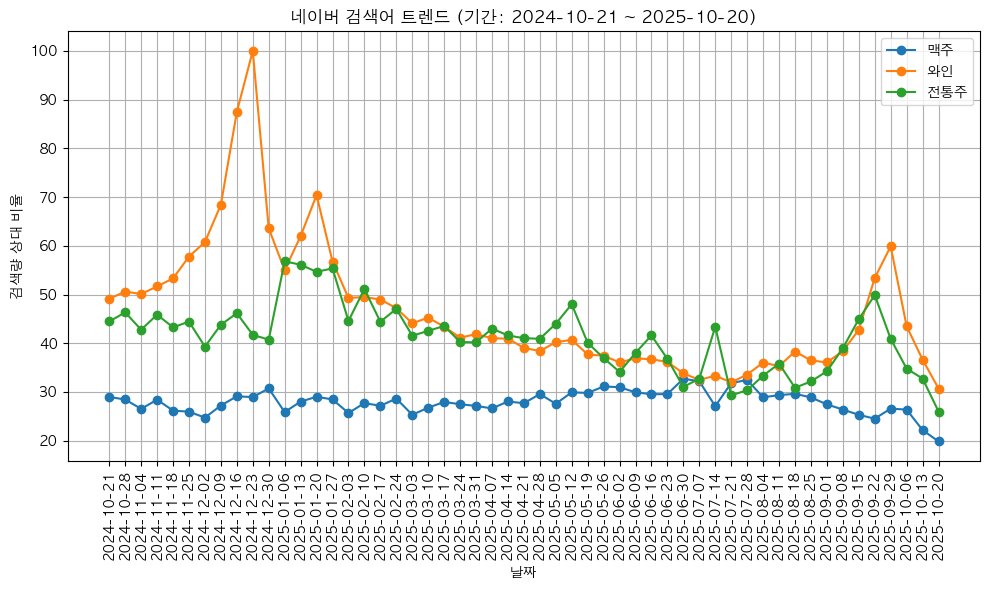

In [ ]:
import matplotlib.pyplot as plt
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10,6))
for title, group in trend_df.groupby("title"):
    plt.plot(group["period"], group["ratio"], marker="o", label=title)

plt.title("네이버 검색어 트렌드 (기간: 2024-10-21 ~ 2025-10-20)")
plt.xlabel("날짜")
plt.ylabel("검색량 상대 비율")
plt.xticks(ticks=group["period"], rotation = 90)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


---

# 설튜터님.ver

In [ ]:
# 네이버 트렌드 API를 이용한 검색어 트렌드 데이터 수집
import requests
import json
import pandas as pd
import matplotlib.pyplot as plt
import os
from datetime import datetime, timedelta

# API 인증 정보 설정
client_id = "YOUR_ID"
client_secret = "YOUr_SECRET"

# 저장 폴더 생성
output_dir = "./naver_trend_data"
os.makedirs(output_dir, exist_ok=True)

# 현재 날짜 기준으로 1년 전까지의 기간 설정
end_date = datetime.now().strftime("%Y-%m-%d")
start_date = (datetime.now() - timedelta(days=365)).strftime("%Y-%m-%d")

# 분석할 키워드 그룹 설정
keyword_groups = [
    {
        "groupName": "패션의류",
        "keywords": ["남성의류", "여성의류", "아우터", "원피스", "티셔츠", "청바지", "패딩"]
    },
    {
        "groupName": "전자제품",
        "keywords": ["스마트폰", "노트북", "태블릿", "이어폰", "스마트워치", "게이밍", "블루투스"]
    },
    {
        "groupName": "화장품뷰티",
        "keywords": ["스킨케어", "립스틱", "선크림", "파운데이션", "마스크팩", "향수", "클렌징"]
    },
    {
        "groupName": "식품구매",
        "keywords": ["배달음식", "밀키트", "건강식품", "간편식", "쌀", "과일", "신선식품"]
    }
]

# API 요청 헤더 설정
headers = {
   "X-Naver-Client-Id": client_id,
   "X-Naver-Client-Secret": client_secret,
   "Content-Type": "application/json"
}

# API 엔드포인트
api_url = "https://openapi.naver.com/v1/datalab/search"

# 요청 본문 데이터
request_body = {
   "startDate": start_date,
   "endDate": end_date,
   "timeUnit": "week",  # 주간 단위로 데이터 요청
   "keywordGroups": keyword_groups,
}

# API 요청 실행
try:
   response = requests.post(
       api_url,
       headers=headers,
       data=json.dumps(request_body)
   )
   
   if response.status_code == 200:
       print("API 요청 성공!")
       result_data = response.json()
       
       # 결과 JSON 파일로 저장
       timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
       json_filename = f"naver_trend_{timestamp}.json"
       json_path = os.path.join(output_dir, json_filename)
       
       with open(json_path, 'w', encoding='utf-8') as f:
           json.dump(result_data, f, ensure_ascii=False, indent=2)
       
       print(f"원본 데이터가 {json_path}에 저장되었습니다.")
       
       # 데이터를 데이터프레임으로 변환
       all_data = []
       
       for result in result_data.get('results', []):
           group_name = result.get('title')
           keywords = result.get('keywords')
           keywords_str = ", ".join(keywords)
           
           for data_point in result.get('data', []):
               period = data_point.get('period')
               ratio = data_point.get('ratio')
               
               all_data.append({
                   '키워드그룹': group_name,
                   '포함키워드': keywords_str,
                   '날짜': period,
                   '검색량비율': ratio
               })
       
       # 데이터프레임 생성
       df = pd.DataFrame(all_data)
       
       # CSV 파일로 저장
       csv_filename = f"naver_trend_{timestamp}.csv"
       csv_path = os.path.join(output_dir, csv_filename)
       df.to_csv(csv_path, index=False, encoding='utf-8-sig')
       
       print(f"가공된 데이터가 {csv_path}에 저장되었습니다.")
   else:
        print(f"API 요청 실패: {response.status_code}")
        print(f"에러 메시지: {response.text}")
except Exception as e:
   print(f"오류 발생: {e}")

In [ ]:
# 데이터 분석 및 시각화
df = pd.read_csv(csv_path)
      
# 각 키워드 그룹별 최대 검색량 시기 찾기
print("\n=== 키워드 그룹별 최대 검색량 시기 ===")
for group_name in df['키워드그룹'].unique():
    group_data = df[df['키워드그룹'] == group_name]
    max_idx = group_data['검색량비율'].idxmax()
    max_date = group_data.loc[max_idx, '날짜']
    max_ratio = group_data.loc[max_idx, '검색량비율']
    
    print(f"{group_name}: {max_date} (검색량 비율: {max_ratio})")

# 데이터 시각화 (그래프로 저장)
plt.figure(figsize=(12, 6))

# 한글 폰트 설정 (윈도우의 경우)
try:
    plt.rc('font', family='Malgun Gothic')
except:
    print("기본 폰트를 사용합니다. (한글이 깨질 수 있습니다)")

# 그래프 그리기
for group_name in df['키워드그룹'].unique():
    group_data = df[df['키워드그룹'] == group_name]
    plt.plot(group_data['날짜'], group_data['검색량비율'], label=group_name, marker='o', markersize=3)

plt.title(f'네이버 검색어 트렌드 (기간: {start_date} ~ {end_date})')
plt.xlabel('날짜')
plt.ylabel('검색량 상대적 비율')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

# 그래프 파일로 저장
graph_filename = f"naver_trend_graph_{timestamp}.png"
graph_path = os.path.join(output_dir, graph_filename)
plt.tight_layout()
plt.savefig(graph_path)

print(f"트렌드 그래프가 {graph_path}에 저장되었습니다.")

# 추가 분석: 그룹별 평균 검색량 
print("\n=== 키워드 그룹별 평균 검색량 비율 ===")
avg_by_group = df.groupby('키워드그룹')['검색량비율'].mean().sort_values(ascending=False)
for group, avg in avg_by_group.items():
    print(f"{group}: {avg:.2f}")